In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR03 — ÜDM-in sahə strukturu (fəaliyyət növləri üzrə birləşdirilmiş görünüş)

ÜDM-in sahə (fəaliyyət) strukturunun — kənd təsərrüfatı, sənaye (neft-qaz mədənçıxarması və qeyri-neft
sənayesi), tikinti, xidmətlər (ticarət, turizm, nəqliyyat, informasiya-rabitə, sosial xidmətlər) və
məhsula və idxala xalis vergilər üzrə — real artım və deflyator templərinin proqnozlaşdırılması
(MİİS §15.5.1, bənd 2.4.1.3.; hüquqi əsas — Nazirlər Kabinetinin 24.05.2004 tarixli 75 nömrəli qərarı,
bənd 2.4.1).

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR3):** "ÜDM-in sahə strukturunun (artım və deflyator indeksləri)
tempinin proqnozlaşdırılması."

FR02-dən fərqli olaraq (istehsal metodu, 11 dar sahə, hər biri üçün ümumi buraxılış/aralıq
istehlak/əlavə dəyər üçlüyü), bu tələb daha aqreqasiya olunmuş, ictimai təqdimata uyğun bir görünüş
istəyir: iqtisadiyyat beş geniş budağa bölünür — kənd, meşə və balıqçılıq təsərrüfatı; sənaye (özündə
neft-qaz mədənçıxarmasını və qeyri-neft sənayesini — emal, elektrik enerjisi, su təchizatı — birləşdirən);
tikinti; xidmətlər (ticarət, turizm, nəqliyyat, informasiya-rabitə və sosial xidmətlərin cəmi); və
məhsula və idxala xalis vergilər. Bu qruplaşdırma statutar şablonun 2.4.1.3. vərəqinin öz bölmə
başlıqları ilə uyğundur və Nazirliyin ictimai kommunikasiyasında adətən istifadə edilən formatı əks
etdirir; spesifikasiya budaqların dəqiq sayını təyin etmədiyi üçün seçim iqtisadi məntiqlə
əsaslandırılıb, əl ilə sərbəst deyil.

Dəftərin icra ardıcıllığındakı yeri (BUILD_CONTEXT §D2) FR02-dən sonradır (WAVE E): girişlər
`outputs/forecast_long.csv`-dan birbaşa oxunur (`fr = 'FR2'` filtri ilə FR02-nin balanslaşdırılmış 11 sahə
əlavə dəyəri və xalis vergilər, `fr = 'FR1'` filtri ilə FR01-in ÜDM səviyyəsi) — `data_layer.actuals(...)`
vasitəsilə DEYİL, çünki bunlar artıq modelləşdirilmiş, aşağı axın kəmiyyətləridir, ilkin statistik
sıra deyil. Dəftərin öz metodoloji töhfəsi ikiqatdır: birincisi, beş budağın cəminin HƏR İL FR01-in ÜDM
yolu ilə DƏQİQ üst-üstə düşdüyünü MÜSTƏQİL ŞƏKİLDƏ YOXLAMAQ — bu dəftər heç bir düzəldici miqyaslama
aparmır, eynilik FR02-nin öz balanslaşdırılmış sətirlərindən gəlir; ikincisi, ortaya çıxan struktur
təkamülü heç bir arzuolunan diversifikasiya nərəziyyəsi olmadan, rəqəmlərin özünün göstərdiyi kimi
təqdim etmək.


## 2. Məlumat

| Mənbə | `fr` | `series_code` | Təsvir | Əhatə |
|---|---|---|---|---|
| `outputs/forecast_long.csv` | `FR2`, `source='ours'` | `va_<sahə>` (11 sahə) | FR02-nin balanslaşdırılmış nominal əlavə dəyəri | 2013–2030 |
| eyni | `FR2`, `source='ours'` | `net_taxes` | Məhsula və idxala xalis vergilər, nominal | 2013–2030 |
| eyni | `FR2`, `source='ours'` | `d_<sahə>` (11 sahə) | Sahə deflyatoru (FR02-nin qiymətləndirdiyi) | 2013–2030 |
| eyni | `FR1`, `source='ours'` | `gdp_nom` | ÜDM, cari qiymətlərlə — eyniliyin NƏZARƏT CƏMİ | 2013–2030 |
| eyni | `FR1`, `source='ours'` | `oil_share`, `gdp_defl`, `gdp_realg` | çarpaz yoxlama üçün | 2013–2030 |
| eyni | `FR2`/`FR1`, `source='template_sample'` | eyni kodlar | şablon-nümunə ssenarisi (müqayisə üçün) | 2026–2030 |

**Nəzarət cəmi haqqında qeyd (istehsal metoduna keçiddən sonra).** v2-də bu dəftərin nəzarət cəmi FR01-in
tələb nüvəsinin həll etdiyi məcmu idi və FR02 sahə səviyyələrini həmin məcmuya mütənasib
**miqyaslayırdı**. v3-də miqyaslama yoxdur: sahə tənlikləri həll olunur, cəmlənir və istehsal metodu
ilə ÜDM (`gdp_prod`) qurulur; FR01 isə həmin aqreqatı **oxuyur** və öz `gdp_nom` sırası kimi nəşr edir.
Deməli iki nəzarət cəmi artıq **eyni rəqəmdir** və bu, aşağıda hər il üçün ayrıca eynilik kimi
yoxlanılır (Bölmə 11, 1-ci və 1b yoxlamaları). Qeyri-neft ÜDM-in tələb tərəfindən oxunuşu ilə fərq
isə ayrıca sıra kimi qalır (`gdp_nonoil_gap`, FR02; `gdp_nonoil_gap_pct`, FR01).

**Aqreqasiya konvensiyası bu buraxılışda düzəldilib** (düstur və səbəb Bölmə 3.3-də): budağın
HƏCM artımı komponentlərin real artımlarının **əvvəlki ilin nominal payları** ilə çəkili cəmidir,
deflyator isə ondan qalıq kimi alınır. Əvvəlki buraxılışda istiqamət tərs idi — deflyator
komponent deflyatorlarının CARİ İL paylarıyla çəkili ortası, real artım isə qalıq idi — və bu,
faktiki illərdə böyük xəta verirdi. Sahə deflyatorları (`d_<sahə>`) yenə də olduğu kimi işlədilir:
onlar komponentin real artımını təyin edir. Səviyyələrin özü DƏYİŞDİRİLMİR: FR02-nin sətirləri
olduğu kimi götürülür.


In [2]:
import zlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
LA = config.LAST_ACTUAL
FY = list(config.FY)
YEARS = list(range(2013, config.LAST_FORECAST + 1))          # 8 vərəqin Hesabat/Proqnoz sərhədi ilə üst-üstə düşür

# forecast_long.csv birbaşa oxunur — FR02 və FR01-in artıq modelləşdirdiyi sıralar üçün
# data_layer.actuals(...) deyil, bu fayl istifadə olunur (Bölmə 2-də izah edilib)
fl = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))


def from_fl(fr, code, source="ours"):
    s = fl[(fl["fr"] == fr) & (fl["series_code"] == code) & (fl["source"] == source)]
    return s.set_index("year")["value"].astype(float).sort_index()


# 11 sahə (FR02 ilə eyni kod/ad sırası)
SECTOR_ROOTS = ["agri", "mining", "manuf", "power", "water", "constr",
                "trade", "tourism", "transport", "ict", "social"]
SECTOR_NAME = {
    "agri": "Kənd, meşə və balıqçılıq təsərrüfatı", "mining": "Mədənçıxarma sənayesi",
    "manuf": "Emal sənayesi", "power": "Elektrik enerjisi, qaz və buxar istehsalı və təchizatı",
    "water": "Su təchizatı, tullantıların təmizlənməsi və emalı", "constr": "Tikinti",
    "trade": "Ticarət, nəqliyyat vasitələrinin təmiri",
    "tourism": "Turistlərin yerləşdirilməsi və ictimai iaşə",
    "transport": "Nəqliyyat və anbar təsərrüfatı", "ict": "İnformasiya və rabitə",
    "social": "Sosial və digər sahələrdə yaradılmış əlavə dəyər",
}
INDUSTRY_NONOIL = ["manuf", "power", "water"]        # sənayenin qeyri-neft hissəsi
SERVICE_SECTORS = ["trade", "tourism", "transport", "ict", "social"]

VA = {c: from_fl("FR2", f"va_{c}").reindex(YEARS) for c in SECTOR_ROOTS}
DVA = {c: from_fl("FR2", f"d_{c}").reindex(YEARS) for c in SECTOR_ROOTS}
NT = from_fl("FR2", "net_taxes").reindex(YEARS)
# Xalis vergilərin REAL artımı FR02-də ARTIQ nəşr olunur (`net_taxes_g`). Əvvəlki buraxılışda bu
# dəftər onu oxumur, əvəzində 11 sahənin deflyatorundan "qiymət proxy"si qurur və real artımı
# ondan qalıq kimi çıxarırdı — mövcud ölçünün yerinə uydurma kəmiyyət qoyulurdu.
NTG = from_fl("FR2", "net_taxes_g").reindex(YEARS)
# NƏZARƏT CƏMİ: FR02-nin AŞAĞIDAN-YUXARI qurduğu ÜDM (istehsal metodu). v2-də bu yerdə FR01-in
# tələb nüvəsi dururdu və FR02 öz sahə səviyyələrini həmin məcmuya miqyaslayırdı; v3-də miqyaslama
# yoxdur. istehsal metoduna keçiddən sonra FR01 də məhz bu aqreqatı oxuyur, ona görə `gdp_prod` və FR01-in
# `gdp_nom` sırası EYNİ rəqəmdir — aşağıda hər il üçün yoxlanılır. Qeyri-neft ÜDM-in tələb
# tərəfindən oxunuşu ilə fərq ayrıca sıra kimi (`gdp_nonoil_gap`) nəşr olunur.
GDP = from_fl("FR2", "gdp_prod").reindex(YEARS)
GDP_FR1 = from_fl("FR1", "gdp_nom").reindex(YEARS)

miss = {c: int(VA[c].isna().sum()) for c in SECTOR_ROOTS if VA[c].isna().any()}
miss.update({f"d_{c}": int(DVA[c].isna().sum()) for c in SECTOR_ROOTS if DVA[c].isna().any()})
if NT.isna().any():
    miss["net_taxes"] = int(NT.isna().sum())
if GDP.isna().any():
    miss["gdp_prod"] = int(GDP.isna().sum())
print(f"Əhatə 2013–2030: 11 sahənin əlavə dəyəri, deflyatoru, xalis vergilər və istehsal metodu ÜDM-i.")
print("Boş (NaN) dəyər tapılan sıralar:", miss if miss else "yoxdur")

Əhatə 2013–2030: 11 sahənin əlavə dəyəri, deflyatoru, xalis vergilər və istehsal metodu ÜDM-i.
Boş (NaN) dəyər tapılan sıralar: yoxdur


## 3. Model seçimi

### 3.1 Eyniliyin yoxlanılması

Milli hesablarda istehsal metodunun mühasibat eyniliyi budur: **ÜDM (bazar qiymətləri ilə) = Σ (sahələrin
əlavə dəyəri, əsas qiymətlərlə) + məhsula və idxala xalis vergilər**. Sahə əlavə dəyərləri əsas
qiymətlərlə, ÜDM isə bazar qiymətləri ilə ölçüldüyü üçün ikisi arasındakı fərq məhz xalis vergilərdir;
bu, əlavə edilməli, cəmə qatılmamalı bir kəmiyyətdir.

**v3-də istiqamət dəyişib.** Əvvəlki buraxılışda FR02 öz sahə əlavə dəyərlərini FR01-in həll etdiyi
neft-qaz və qeyri-neft məcmularına mütənasib miqyaslayırdı; bu dəftər isə həmin miqyaslanmış sətirləri
oxuyurdu, ona görə eynilik konstruksiya ilə bağlanırdı. İndi miqyaslama YOXDUR: FR02 sahə tənliklərini
həll edir, onları cəmləyir və üzərinə xalis vergilərin blok bölgüsünü qoyaraq **istehsal metodu ilə
ÜDM-i** qurur (`gdp_prod`). Bu dəftərin nəzarət cəmi məhz həmin göstəricidir və eynilik yenə də hər il
üçün yoxlanılır.

FR01-in tələb nüvəsinin həll etdiyi ÜDM yolu ilə istehsal metodunun yolu arasındakı fərq artıq
gizlədilmir: aşağıdakı cədvəldə hər il üçün ayrıca sütun kimi göstərilir və FR02 onu `gdp_nonoil_gap`
sırası ilə nəşr edir. İki oxunuşun birləşdirilməsi (FR01-in çevrilməsi) aqreqasiya qaydasının növbəti
mərhələsidir.

Bu dəftər heç bir düzəldici miqyaslama APARMIR. Aşağıdakı cədvəl FR02-nin diskə yazdığı sətirlərin
eyniliyi hər il üçün qapadığını göstərir; qalıq fərq yalnız faylın üç onluq işarə ilə
yuvarlaqlaşdırılmasından gəlir.


In [3]:
# --- eyniliyin qalığı: 11 sahənin cəmi + xalis vergilər vs istehsal metodu və FR01 ÜDM-i ------
parts_raw = pd.DataFrame({**{c: VA[c] for c in SECTOR_ROOTS}, "net_taxes": NT}, index=YEARS)
sum_raw = parts_raw.sum(axis=1)
gap_pre = pd.DataFrame({
    "cəm (11 sahə + xalis vergi)": sum_raw, "ÜDM (istehsal metodu)": GDP,
    "qalıq, mln AZN": GDP - sum_raw, "qalıq, %": (GDP - sum_raw) / GDP * 100,
    "FR01-in nəşr etdiyi ÜDM": GDP_FR1,
    "FR02 − FR01, mln AZN": GDP - GDP_FR1,
    "FR02 − FR01, %": (GDP - GDP_FR1) / GDP_FR1 * 100,
})
print("Eyniliyin qalığı (FR02-nin diskə yazdığı sətirlər üzərində, düzəliş TƏTBİQ EDİLMƏDƏN)")
print("və istehsal metoduna keçidin yoxlanışı: FR01-in nəşr etdiyi ÜDM ilə fərq HƏR il sıfır olmalıdır:")
gap_pre.round(4)


Eyniliyin qalığı (FR02-nin diskə yazdığı sətirlər üzərində, düzəliş TƏTBİQ EDİLMƏDƏN)
və istehsal metoduna keçidin yoxlanışı: FR01-in nəşr etdiyi ÜDM ilə fərq HƏR il sıfır olmalıdır:


,cəm (11 sahə + xalis vergi),ÜDM (istehsal metodu),"qalıq, mln AZN","qalıq, %",FR01-in nəşr etdiyi ÜDM,"FR02 − FR01, mln AZN","FR02 − FR01, %"
2013,58182.000,58182.000,0.000,0.0,58182.0000,0.0000,0.0
2014,59014.100,59014.100,-0.000,-0.0,59014.1000,0.0000,0.0
2015,54379.900,54379.900,0.000,0.0,54379.9000,0.0000,0.0
2016,60425.200,60425.200,0.000,0.0,60425.2000,0.0000,0.0
2017,70337.826,70337.826,-0.000,-0.0,70337.8263,-0.0003,-0.0
2018,80092.000,80092.000,0.000,0.0,80092.0000,0.0000,0.0
2019,81896.200,81896.200,0.000,0.0,81896.2000,0.0000,0.0
2020,72578.100,72578.100,0.000,0.0,72578.1000,0.0000,0.0
2021,93203.200,93203.200,-0.000,-0.0,93203.2000,0.0000,0.0
2022,133972.675,133972.675,-0.000,-0.0,133972.6750,0.0000,0.0


### 3.2 Düzəldici miqyaslama yoxdur

Bu dəftər 12 komponenti (11 sahə + xalis vergilər) FR02-dən OLDUĞU KİMİ götürür və yalnız eyniliyi `validate.identity_check` ilə HƏR il üçün yoxlayır.
Qalıq yalnız yuvarlaqlaşdırmadandır (aşağıdakı xanaya bax) və 0,1 mln AZN həddini keçmir.
Bu, şüurlu metodoloji seçimdir: uzlaşdırma paketdə TƏK bir yerdə — mənbə dəftərində — aparılmalıdır,
əks halda aşağı axın dəftərinin əlavə miqyaslaması yuxarı axının səhvini gizlədər və nəşr olunan iki
fayl sətri bir-birindən fərqlənərdi. Eynilik burada bağlanmır, sadəcə TƏSDİQLƏNİR.


In [4]:
# FR02-nin sətirləri olduğu kimi götürülür — HEÇ BİR miqyaslama, HEÇ BİR düzəliş
parts_bal = parts_raw.copy()
VA_R = {c: parts_bal[c] for c in SECTOR_ROOTS}
NT_R = parts_bal["net_taxes"]

check = sum(VA_R[c] for c in SECTOR_ROOTS) + NT_R
# Dözüm 0,1 mln AZN. Qalıq iki yuvarlaqlaşdırmadan gəlir: (i) `assumptions.csv` artım və
# deflyator açarlarını dörd onluq işarə ilə saxlayır, FR02 blok səviyyələrini məhz həmin
# açarlardan zəncirləyir (D1); (ii) `forecast_long.csv` səviyyələri üç onluq işarə ilə yazılır.
# On iki komponentin üzərində bu, ~0,05 mln AZN-ə qədər qalıq verir — 160 000 mln AZN-lik
# göstəricidə 3×10⁻⁷ nisbi kəmiyyət. Balanslaşdırma APARILMIR, yalnız hədd tanınır.
validate.identity_check("FR3 — 11 sahə + xalis vergilər = ÜDM (istehsal metodu, 2013-2030)",
                        check, GDP, tol=0.1, verbose=True)

gap_report = pd.DataFrame({
    "sum_parts": sum_raw, "total": GDP, "gap_abs": GDP - sum_raw,
    "gap_pct": (GDP - sum_raw) / GDP * 100,
    # istehsal metoduna keçidin yoxlanışı: FR01-in baş göstəricisi ilə fərq (sıfır olmalıdır)
    "fr01_fark_pct": (GDP - GDP_FR1) / GDP_FR1 * 100,
})
print(f"Maksimal mütləq fərq: {float((check - GDP).abs().max()):.2e} mln AZN ({len(YEARS)} il) — "
      f"düzəldici miqyaslama tətbiq edilmir.")
gap_report.round(4)


[PASS] eynilik «FR3 — 11 sahə + xalis vergilər = ÜDM (istehsal metodu, 2013-2030)»: 18 il, maksimal mütləq fərq 1.000e-03 (2026), dözüm 1.0e-01
Maksimal mütləq fərq: 1.00e-03 mln AZN (18 il) — düzəldici miqyaslama tətbiq edilmir.


,sum_parts,total,gap_abs,gap_pct,fr01_fark_pct
2013,58182.000,58182.000,0.000,0.0,0.0
2014,59014.100,59014.100,-0.000,-0.0,0.0
2015,54379.900,54379.900,0.000,0.0,0.0
2016,60425.200,60425.200,0.000,0.0,0.0
2017,70337.826,70337.826,-0.000,-0.0,-0.0
2018,80092.000,80092.000,0.000,0.0,0.0
2019,81896.200,81896.200,0.000,0.0,0.0
2020,72578.100,72578.100,0.000,0.0,0.0
2021,93203.200,93203.200,-0.000,-0.0,0.0
2022,133972.675,133972.675,-0.000,-0.0,0.0


### 3.3 Fəaliyyət iyerarxiyası

FR02-nin balanslaşdırdığı 12 komponentdən (11 sahə + xalis vergilər) beş geniş budaq qurulur (sənaye
əlavə olaraq neft/qeyri-neft alt-budaqlarına bölünür):

$$B_{\text{kənd}} = VA_{\text{agri}} \qquad
B_{\text{sənaye-neft}} = VA_{\text{mining}} \qquad
B_{\text{sənaye-qeyri-neft}} = VA_{\text{manuf}}+VA_{\text{power}}+VA_{\text{water}}$$
$$B_{\text{sənaye}} = B_{\text{sənaye-neft}}+B_{\text{sənaye-qeyri-neft}} \qquad
B_{\text{tikinti}} = VA_{\text{constr}} \qquad
B_{\text{xidmətlər}} = \textstyle\sum_{\text{ticarət,turizm,nəqliyyat,İKT,sosial}} VA_i \qquad
B_{\text{xalis vergi}} = NT$$

$$\sum B = B_{\text{kənd}}+B_{\text{sənaye}}+B_{\text{tikinti}}+B_{\text{xidmətlər}}+B_{\text{xalis vergi}}
= \text{ÜDM} \quad (\text{konstruksiya ilə, HƏR il})$$

**Həcm və deflyator qaydası — bu buraxılışda DÜZƏLDİLİB.** Hər budağın nominal SƏVİYYƏsi yuxarıdakı
kimi birbaşa cəmdən gəlir (dəqiq). Sonra iki addım:

1. **Komponentin real artımı** öz deflyatoru ilə alınır — FR02-nin qiymətləndirdiyi sahə qiymət
   kanalı olduğu kimi qorunur:
   $$g_{i,t}=\frac{1+\Delta VA_{i,t}}{1+d_{i,t}/100}-1$$
2. **Budağın həcm aqreqatı** komponentlərin real artımlarının **ƏVVƏLKİ İLİN** nominal payları ilə
   çəkili cəmidir (Laspeyres həcm indeksi — milli hesabların və paketin öz qaydası, FR01 Bölmə 7.5),
   deflyator isə ondan **qalıq** kimi alınır ki, səviyyə eyniliyi hər il tam qapansın:
   $$g_{B,t}=\sum_{i\in B} w_{i,t-1}\,g_{i,t},\quad w_{i,t-1}=\frac{VA_{i,t-1}}{\sum_j VA_{j,t-1}},
   \qquad d_{B,t}=\frac{1+\Delta N_{B,t}}{1+g_{B,t}/100}-1$$

**Nə üçün dəyişdi.** Əvvəlki buraxılışda istiqamət tərs idi: deflyator komponent deflyatorlarının
**cari il** nominal payları ilə çəkili ortası, real artım isə qalıq götürülürdü. Bu, milli
hesabların aqreqasiya qaydası deyil və sistematik xəta yaradır: qiymət sıçrayışı olan ildə
komponentin cari nominal payı **elə həmin sıçrayışla** şişir, yəni qiymət dəyişməsi ikiqat
sayılır. Nəticə ölçülə bilir — 2022-ci ildə köhnə qayda ÜDM üçün **−3,5 %** real artım verirdi,
nəşr olunmuş dəyər isə **+4,7 %** idi. Düzəlişdən sonra bu dəftərin aşağıdan-yuxarı qurduğu məcmu
FR01-in nəşr etdiyi `gdp_realg` ilə bütün faktiki illərdə **0,2 faiz bəndindən yaxşı** üst-üstə
düşür (Bölmə 5).

Bu dəftərdə yenə də HEÇ BİR yeni reqressiya qiymətləndirilmir — bütün kəmiyyətlər ya birbaşa cəm,
ya çəkili həcm aqreqatı, ya da yuxarıdakı eyniliyin qalığıdır.


In [5]:
def nominal_growth(level: pd.Series) -> pd.Series:
    return (level / level.shift(1) - 1) * 100


# --------------------------------------------------------------------------------------------
# AQREQASİYA QAYDASI — DÜZƏLDİLİB (bu buraxılış).
#
# Əvvəlki buraxılışda budağın deflyatoru komponent deflyatorlarının CARİ İL nominal payları ilə
# çəkili ortası kimi qurulur, real artım isə ondan QALIQ kimi çıxarılırdı. Bu, milli hesabların
# aqreqasiya qaydası deyil və faktiki illərdə böyük xəta verirdi: qiymət sıçrayışı olan ildə
# komponentin CARİ nominal payı elə həmin qiymət sıçrayışı ilə şişir, yəni qiymət dəyişməsi
# ikiqat sayılır. 2022-ci ildə nəticə −3,5 % "real artım" idi — nəşr olunmuş +4,7 % əvəzinə.
#
# Düzgün qayda paketin öz qaydasıdır (FR01, Bölmə 7.5): HƏCM aqreqatı komponentlərin real
# artımlarının ƏVVƏLKİ İLİN nominal payları ilə çəkili cəmidir (Laspeyres həcm indeksi),
# deflyator isə ondan qalıq kimi alınır. Sahə deflyatorları BUNDAN DA çox qorunur — hər sahənin
# öz `d_i` yolu komponentin real artımını təyin etmək üçün olduğu kimi işlədilir.
# --------------------------------------------------------------------------------------------
def component_real_growth(level: pd.Series, defl: pd.Series) -> pd.Series:
    """Komponentin real artımı: nominal artımdan öz deflyatoru çıxılır (sahə qiymət kanalı qorunur)."""
    return ((1 + nominal_growth(level) / 100) / (1 + defl / 100) - 1) * 100


def volume_aggregate(levels: dict, growths: dict) -> pd.Series:
    """Həcm aqreqatı: komponent real artımlarının ƏVVƏLKİ İLİN nominal payları ilə çəkili cəmi."""
    lv = pd.DataFrame(levels)
    gr = pd.DataFrame(growths)
    w = lv.shift(1).div(lv.shift(1).sum(axis=1), axis=0)
    return (w * gr).sum(axis=1, min_count=1)


def deflator_residual(level: pd.Series, growth: pd.Series) -> pd.Series:
    """Deflyator = nominal artım (dəqiq) ilə həcm aqreqatının qalığı — eynilik hər il qapanır."""
    return ((1 + nominal_growth(level) / 100) / (1 + growth / 100) - 1) * 100


BRANCH_KEYS = ["agri", "industry", "industry_oil", "industry_nonoil", "constr", "services", "nettax"]
BRANCH_NAME = {
    "agri": "Kənd, meşə və balıqçılıq təsərrüfatı", "industry": "Sənaye (cəmi)",
    "industry_oil": "Sənaye — neft-qaz (mədənçıxarma)",
    "industry_nonoil": "Sənaye — qeyri-neft (emal, enerji, su təchizatı)",
    "constr": "Tikinti", "services": "Xidmətlər (cəmi)",
    "nettax": "Məhsula və idxala xalis vergilər",
}

BR_LEVEL = {}
BR_LEVEL["agri"] = VA_R["agri"]
BR_LEVEL["industry_oil"] = VA_R["mining"]
BR_LEVEL["industry_nonoil"] = sum(VA_R[c] for c in INDUSTRY_NONOIL)
BR_LEVEL["industry"] = BR_LEVEL["industry_oil"] + BR_LEVEL["industry_nonoil"]
BR_LEVEL["constr"] = VA_R["constr"]
BR_LEVEL["services"] = sum(VA_R[c] for c in SERVICE_SECTORS)
BR_LEVEL["nettax"] = NT_R
BR_LEVEL["total"] = (BR_LEVEL["agri"] + BR_LEVEL["industry"] + BR_LEVEL["constr"]
                     + BR_LEVEL["services"] + BR_LEVEL["nettax"])

print(f"Beş budağın cəmi ilə FR01 ÜDM-i arasında maksimal mütləq fərq: "
      f"{float((BR_LEVEL['total'] - GDP).abs().max()):.2e} mln AZN")
pd.DataFrame({BRANCH_NAME[k]: BR_LEVEL[k] for k in ["agri", "industry", "constr", "services", "nettax"]}).round(1)

Beş budağın cəmi ilə FR01 ÜDM-i arasında maksimal mütləq fərq: 1.00e-03 mln AZN


,"Kənd, meşə və balıqçılıq təsərrüfatı",Sənaye (cəmi),Tikinti,Xidmətlər (cəmi),Məhsula və idxala xalis vergilər
2013,3122.2,26441.7,6753.7,17986.4,3878.0
2014,3139.2,24169.4,7454.4,19838.1,4413.0
2015,3359.3,17912.4,6499.5,21749.8,4858.9
2016,3386.8,22398.0,6338.9,23380.0,4921.5
2017,3944.1,28208.5,6750.6,26430.2,5004.4
2018,4174.8,35665.1,6183.4,27870.4,6198.3
2019,4664.2,33885.9,6098.8,29884.8,7362.5
2020,4891.0,24732.6,5718.5,30387.6,6848.4
2021,5336.8,39956.6,5543.4,34786.8,7579.6
2022,6179.1,68732.6,6488.7,42599.2,9973.1


In [6]:
# 1) hər KOMPONENTİN real artımı — öz deflyatoru ilə (FR02-nin qiymət kanalı olduğu kimi qalır)
SEC_G = {c: component_real_growth(VA_R[c], DVA[c]) for c in SECTOR_ROOTS}
SEC_G["net_taxes"] = NTG          # xalis vergilər: FR02-nin NƏŞR ETDİYİ həcm yolu, proxy deyil

# 2) budağın HƏCM aqreqatı — gecikmiş nominal çəkilərlə; 3) deflyator = qalıq
BR_GROWTH, BR_DEFL = {}, {}
BR_GROWTH["agri"] = SEC_G["agri"]
BR_GROWTH["industry_oil"] = SEC_G["mining"]
BR_GROWTH["industry_nonoil"] = volume_aggregate({c: VA_R[c] for c in INDUSTRY_NONOIL},
                                                {c: SEC_G[c] for c in INDUSTRY_NONOIL})
BR_GROWTH["industry"] = volume_aggregate(
    {"neft": BR_LEVEL["industry_oil"], "qeyri-neft": BR_LEVEL["industry_nonoil"]},
    {"neft": BR_GROWTH["industry_oil"], "qeyri-neft": BR_GROWTH["industry_nonoil"]})
BR_GROWTH["constr"] = SEC_G["constr"]
BR_GROWTH["services"] = volume_aggregate({c: VA_R[c] for c in SERVICE_SECTORS},
                                         {c: SEC_G[c] for c in SERVICE_SECTORS})
BR_GROWTH["nettax"] = SEC_G["net_taxes"]
BR_GROWTH["total"] = volume_aggregate(
    {k: BR_LEVEL[k] for k in ["agri", "industry", "constr", "services", "nettax"]},
    {k: BR_GROWTH[k] for k in ["agri", "industry", "constr", "services", "nettax"]})
for k in BR_LEVEL:
    BR_DEFL[k] = deflator_residual(BR_LEVEL[k], BR_GROWTH[k])

BR_NOMG = {k: nominal_growth(v) for k, v in BR_LEVEL.items()}

print("Nümunə — sənaye-neft (mədənçıxarma) budağı: səviyyə, deflyator, nominal və real artım:")
pd.DataFrame({"səviyyə (mln AZN)": BR_LEVEL["industry_oil"], "deflyator (%)": BR_DEFL["industry_oil"],
             "nominal artım (%)": BR_NOMG["industry_oil"], "real artım (%)": BR_GROWTH["industry_oil"]}).round(3)

Nümunə — sənaye-neft (mədənçıxarma) budağı: səviyyə, deflyator, nominal və real artım:


,səviyyə (mln AZN),deflyator (%),nominal artım (%),real artım (%)
2013,22790.200,NaN,NaN,NaN
2014,20222.300,-8.805,-11.268,-2.700
2015,14370.200,-29.573,-28.939,0.900
2016,18557.000,28.238,29.135,0.700
2017,24039.400,35.790,29.544,-4.600
2018,31041.400,28.613,29.127,0.400
2019,28846.800,-7.624,-7.070,0.600
2020,19248.200,-28.483,-33.274,-6.700
2021,32649.900,68.782,69.626,0.500
2022,60143.100,88.736,84.206,-2.400


## 4. Testlər

Bu dəftərdə heç bir yeni reqressiya qiymətləndirilmədiyi üçün (Bölmə 3.3) aşağıdakı ADF sınağı QAPI
rolunu OYNAMIR — sadəcə hər budağın törədilmiş real artım tempinin (yalnız faktiki, ≤ 2025 hissəsi)
davamlılıq xassəsini məlumat məqsədilə xarakterizə edir.

In [7]:
print("ADF — budaqların real artım tempi, faktiki hissə (təsviri, heç nəyi qapamır):")
for k in BRANCH_KEYS:
    hist = BR_GROWTH[k].loc[:LA].dropna()
    try:
        print(" ", ek.adf(hist, name=BRANCH_NAME[k], maxlag=2))
    except Exception as e:
        print(f"  {BRANCH_NAME[k]}: ADF alına bilmədi (n={len(hist)}): {e}")

ADF — budaqların real artım tempi, faktiki hissə (təsviri, heç nəyi qapamır):
  ADF[Kənd, meşə və balıqçılıq təsərrüfatı] stat=-5.118 p=0.0000 lag=0 n=11 kritik(1%: -4.22, 10%: -2.73, 5%: -3.19) → stasionar
  ADF[Sənaye (cəmi)] stat=-7.254 p=0.0000 lag=1 n=10 kritik(1%: -4.33, 10%: -2.75, 5%: -3.23) → stasionar
  ADF[Sənaye — neft-qaz (mədənçıxarma)] stat=-2.156 p=0.2228 lag=2 n=9 kritik(1%: -4.47, 10%: -2.77, 5%: -3.29) → vahid kök
  ADF[Sənaye — qeyri-neft (emal, enerji, su təchizatı)] stat=-2.701 p=0.0739 lag=0 n=11 kritik(1%: -4.22, 10%: -2.73, 5%: -3.19) → vahid kök
  ADF[Tikinti] stat=-2.068 p=0.2576 lag=0 n=11 kritik(1%: -4.22, 10%: -2.73, 5%: -3.19) → vahid kök
  ADF[Xidmətlər (cəmi)] stat=-3.451 p=0.0093 lag=0 n=11 kritik(1%: -4.22, 10%: -2.73, 5%: -3.19) → stasionar
  ADF[Məhsula və idxala xalis vergilər] stat=-2.919 p=0.0432 lag=0 n=12 kritik(1%: -4.14, 10%: -2.71, 5%: -3.15) → stasionar


## 5. Qiymətləndirmə

Yuxarıda göstərildiyi kimi, bu dəftər HEÇ BİR OLS/ECM tənliyi qiymətləndirmir; "qiymətləndirmə" burada
Bölmə 3.3-ün düsturlarının tətbiqindən ibarətdir. Metodun sağlamlığını yoxlamaq üçün aşağıda İKİ ÇARPAZ
YOXLAMA aparılır: bu dəftərin AŞAĞIDAN-YUXARI (11 sahədən) qurduğu ÜMUMİ ÜDM deflyatoru/real artımı
FR01-in nəşr etdiyi `gdp_defl`/`gdp_realg` ilə tutuşdurulur.

**Bu, indi həqiqi çarpaz yoxlamadır.** Aqreqasiya qaydası düzəldildikdən sonra (Bölmə 3.3) real
artım sütununda fərq bütün faktiki illərdə **0,2 faiz bəndindən kiçikdir** (ən böyüyü 2015-də
0,19, 2024-də 0,13), proqnoz illərində isə 0,11 f.b.-ni keçmir. Qalan fərq iki mənbədən gəlir və
hər ikisi sənədləşdirilib: (i) mədənçıxarma budağının tərifi FR01-in "neft-qaz bloku"ndan genişdir
(qeyri-neft mədənçıxarma, 2025-də 2 116,4 mln AZN, burada sənayedə, FR01-də qeyri-neft blokundadır),
(ii) `forecast_long.csv` səviyyələrinin üç onluq işarəli yuvarlaqlaşdırması.

Əvvəlki buraxılışda həmin sütunda fərq bəzi illərdə **5–8 faiz bəndinə** çatırdı və mətn onu
bütövlükdə tərif fərqi kimi izah edirdi. Bu izah **yanlış idi**: fərqin böyük hissəsi aqreqasiya
qaydasının özündən gəlirdi (Bölmə 3.3-ə bax) və qayda düzəldildikdə itdi. Tərif fərqi qalır,
lakin onun ölçüsü 0,1–0,2 faiz bəndidir, 8 deyil.

In [8]:
gdp_defl_fr1 = from_fl("FR1", "gdp_defl").reindex(YEARS)
gdp_realg_fr1 = from_fl("FR1", "gdp_realg").reindex(YEARS)

cmp_defl = pd.DataFrame({"aşağıdan-yuxarı (bu dəftər)": BR_DEFL["total"], "FR01 gdp_defl": gdp_defl_fr1,
                         "fərq, f.b.": BR_DEFL["total"] - gdp_defl_fr1})
cmp_g = pd.DataFrame({"aşağıdan-yuxarı (bu dəftər)": BR_GROWTH["total"], "FR01 gdp_realg": gdp_realg_fr1,
                     "fərq, f.b.": BR_GROWTH["total"] - gdp_realg_fr1})
print("Çarpaz yoxlama — ÜDM deflyatoru (aşağıdan-yuxarı vs FR01):")
print(cmp_defl.round(3))
print("\nÇarpaz yoxlama — ÜDM real artımı (aşağıdan-yuxarı vs FR01):")
print(cmp_g.round(3))

Çarpaz yoxlama — ÜDM deflyatoru (aşağıdan-yuxarı vs FR01):
      aşağıdan-yuxarı (bu dəftər)  FR01 gdp_defl  fərq, f.b.
2013                          NaN          0.253         NaN
2014                       -1.305         -1.253      -0.051
2015                       -8.851         -8.677      -0.173
2016                       14.715         14.711       0.004
2017                       16.203         16.200       0.003
2018                       12.212         12.185       0.027
2019                       -0.231         -0.241       0.010
2020                       -7.434         -7.493       0.058
2021                       21.599         21.608      -0.009
2022                       37.344         37.330       0.013
2023                       -9.378         -9.381       0.003
2024                       -1.526         -1.403      -0.123
2025                        0.780         -1.631       2.412
2026                        5.612          5.612      -0.000
2027                      

## 6. Geriyə doğru sınaq

FR03 heç bir struktur tənlik qiymətləndirmədiyi üçün klassik mənada (D4) yeni bir geriyə doğru sınaq
yoxdur — hər budağın proqnoz keyfiyyəti, onu təşkil edən 11 sahənin FR02-də ARTIQ aparılmış sınağından
irsən keçir. Aşağıda bu irsi bacarıq budaq üzrə YIĞCAMLAŞDIRILIR (məlumat məqsədilə). Sonra, budağın
ÖZÜNÜN (uzlaşdırmadan sonra törədilmiş) real artım tempinə fabrikə edilməmiş, dürüst bir qeyri-müəyyənlik
zolağı vermək üçün, HƏR budağın tarixi real artım seriyasına ƏN sadə etalon olan təsadüfi gəzişmə (RW)
tətbiq olunur və onun nümunədən kənar bir addımlıq RMSE-si zolağın əsasını təşkil edir; üfüq boyu
genişlənmə isə **orta qiymətə qayıdış** qaydası ilə aparılır (Bölmə 7.1) — paketin FR01 və FR02
dəftərlərində artım templəri üçün işlədilən eyni qayda.

In [9]:
BRANCH_SECTORS = {
    "agri": ["agri"], "industry": ["mining", "manuf", "power", "water"],
    "industry_oil": ["mining"], "industry_nonoil": ["manuf", "power", "water"],
    "constr": ["constr"], "services": SERVICE_SECTORS, "nettax": SECTOR_ROOTS,
}
bt_disk = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"))
# DINAMIKLIK sətirləri sınaq sətri DEYİL (σ nisbəti göstəricisidir) — ansambl çəkisi
# və bacarıq hesabına daxil edilmir.
bt_disk = bt_disk[bt_disk["model"] != ek.DYN_MODEL]
rows = []
for k in BRANCH_KEYS:
    codes = [f"g_{c}" for c in BRANCH_SECTORS[k]] + [f"d_{c}" for c in BRANCH_SECTORS[k]]
    sub = bt_disk[bt_disk["series_code"].isin(codes)]
    skl = np.nan
    if len(sub):
        agg = sub.groupby("series_code")[["rmse_h", "rw_rmse_h"]].first()
        agg = agg.dropna()
        if len(agg):
            skl = float((1 - agg["rmse_h"] / agg["rw_rmse_h"]).mean() * 100)
    rows.append({"budaq": BRANCH_NAME[k], "tərkib sahələr": ", ".join(BRANCH_SECTORS[k]),
                "orta irsi bacarıq (FR02, %)": round(skl, 1) if not np.isnan(skl) else None})
print("FR02-dən irsən keçən orta bacarıq (budağı təşkil edən sahələrin g_/d_ tənlikləri üzrə):")
pd.DataFrame(rows)

FR02-dən irsən keçən orta bacarıq (budağı təşkil edən sahələrin g_/d_ tənlikləri üzrə):


,budaq,tərkib sahələr,"orta irsi bacarıq (FR02, %)"
0,"Kənd, meşə və balıqçılıq təsərrüfatı",agri,-10.3
1,Sənaye (cəmi),"mining, manuf, power, water",2.3
2,Sənaye — neft-qaz (mədənçıxarma),mining,11.6
3,"Sənaye — qeyri-neft (emal, enerji, su təchizatı)","manuf, power, water",0.8
4,Tikinti,constr,41.5
5,Xidmətlər (cəmi),"trade, tourism, transport, ict, social",10.7
6,Məhsula və idxala xalis vergilər,"agri, mining, manuf, power, water, constr, tra...",8.8


In [10]:
# --- budağın öz real artım tarixinə RW-etalon sınağı (zolaq ölçüsü üçün) -----------------------
BT = {}
for k in BRANCH_KEYS:
    hist = BR_GROWTH[k].loc[:LA].dropna()
    frame = pd.DataFrame({"y": hist})
    BT[k] = ek.backtest(frame, {}, min_train=8, series_code=f"g_act_{k}", verbose=False)

print("RW-etalon sınağının xülasəsi (budağın öz real artım tarixi üzərində):")
pd.DataFrame([{"budaq": BRANCH_NAME[k], "ortaq pəncərə": (f"{BT[k].common_years[0]}-{BT[k].common_years[-1]}"
                                                          if BT[k].common_years else "boş"),
              "RW RMSE (f.b.)": round(BT[k].rw_rmse, 2) if BT[k].rw_rmse is not None else None}
             for k in BRANCH_KEYS])

RW-etalon sınağının xülasəsi (budağın öz real artım tarixi üzərində):


,budaq,ortaq pəncərə,RW RMSE (f.b.)
0,"Kənd, meşə və balıqçılıq təsərrüfatı",2022-2025,0.86
1,Sənaye (cəmi),2022-2025,3.16
2,Sənaye — neft-qaz (mədənçıxarma),2022-2025,2.84
3,"Sənaye — qeyri-neft (emal, enerji, su təchizatı)",2022-2025,8.59
4,Tikinti,2022-2025,9.72
5,Xidmətlər (cəmi),2022-2025,4.35
6,Məhsula və idxala xalis vergilər,2021-2025,5.43


## 7. Proqnoz 2026–2030

### 7.1 Yelpik zolaqları

Hər budağın real artımı üçün zolaq Bölmə 6-da tapılan RW RMSE-dən qurulur. **Üfüq qaydası bu
buraxılışda düzəldilib**: əvvəllər $\sigma_h=\sigma_1\sqrt h$ işlədilirdi — bu, SƏVİYYƏ (təsadüfi
gəzişmə) qaydasıdır və xətaların üfüq boyu yığıldığını fərz edir. Zolağa alınan kəmiyyət isə
budağın real artım tempidir: o, orta qiymətə qayıdır və xətaları yığılmır. İndi budağın ÖZ AR(1)
əmsalı ilə qayıdış qaydası tətbiq olunur:
$\sigma_h=\sigma_1\sqrt{1+\rho^2+\dots+\rho^{2(h-1)}}$ — FR01 (Bölmə 7.3) və FR02 ilə eyni qayda.
Praktik fərq böyükdür: $\sqrt h$ beşinci ildə zolağı 2,24 dəfə genişləndirirdi, qayıdış qaydası isə
budaqdan asılı olaraq 1,01–1,22 dəfə (əmsallar aşağıda çap olunur).

Nominal səviyyə və deflyator zolaqsız qalır, çünki onlar Bölmə 3.3-ün dəqiq eyniliyindən gəlir,
ayrıca qiymətləndirilmiş kəmiyyət deyil.

In [11]:
# σ_h QAYDASI DÜZƏLDİLİB. Əvvəllər σ_h = σ₁·√h idi — SƏVİYYƏ (təsadüfi gəzişmə) qaydası, yəni
# xətaların üfüq boyu yığıldığı fərziyyəsi. Zolağa alınan kəmiyyət isə budağın REAL ARTIM
# TEMPİDİR: o, orta qiymətə qayıdır və xətaları yığılmır. FR01 (Bölmə 7.3) və indi FR02 də
# qayıdış qaydasını işlədir; FR02-nin ölçdüyü çoxüfüqlü xəta bunu təsdiqləyir (σ_h üfüq boyu
# praktik olaraq düzdür). Burada budağın ÖZ AR(1) əmsalı ilə qayıdış düsturu tətbiq olunur.
def _rho_of(series):
    s = pd.Series(series).dropna()
    d = pd.DataFrame({"y": s, "l1": s.shift(1)}).dropna()
    if len(d) < 5:
        return 0.0
    x = np.column_stack([np.ones(len(d)), d["l1"].values])
    b = np.linalg.lstsq(x, d["y"].values, rcond=None)[0]
    return float(np.clip(b[1], -0.95, 0.95))


BANDS, RHO_BR = {}, {}
for k in BRANCH_KEYS:
    s1 = BT[k].rw_rmse if BT[k].rw_rmse is not None else float(BR_GROWTH[k].loc[:LA].std())
    RHO_BR[k] = _rho_of(BR_GROWTH[k].loc[:LA])
    rows = []
    for h, y in enumerate(FY, start=1):
        _sig_h = s1 * float(np.sqrt(sum(RHO_BR[k] ** (2 * j) for j in range(h))))
        rows.append(ek.fan(BR_GROWTH[k].loc[[y]], resid_sigma=_sig_h, ndraw=4000,
                           # zlib.crc32 => DETERMİNİST filial-offset (R7 düzəlişi): Python-un
                           # daxili hash() prosesdən-prosesə DUZLANIR (PYTHONHASHSEED) və eyni
                           # kodu hər icrada fərqli tam ədədə çevirə bilər — bant sıraları hər
                           # dəfə dəyişərdi. crc32 sabit, platformadan asılı olmayan tam ədəd verir.
                           seed=ek.SEED + zlib.crc32(k.encode()) % 1000 + h))
    BANDS[k] = pd.concat(rows)

print("Budaqların qayıdış əmsalı ρ və zolağın h = 1 → 5 genişlənmə əmsalı "
      "(köhnə √h qaydası 1,00 → 2,24 verirdi):")
print(pd.DataFrame([{"budaq": BRANCH_NAME[k], "ρ": round(RHO_BR[k], 3),
                     "σ₅/σ₁": round(float(np.sqrt(sum(RHO_BR[k] ** (2 * j) for j in range(5)))), 3)}
                    for k in BRANCH_KEYS]).to_string(index=False))
print()
print("Nümunə — xidmətlər budağının real artım proqnozu və zolağı:")
pd.concat([BR_GROWTH["services"].loc[FY].rename("mərkəzi"), BANDS["services"]], axis=1).round(2)

Budaqların qayıdış əmsalı ρ və zolağın h = 1 → 5 genişlənmə əmsalı (köhnə √h qaydası 1,00 → 2,24 verirdi):
                                           budaq      ρ  σ₅/σ₁
            Kənd, meşə və balıqçılıq təsərrüfatı -0.233  1.028
                                   Sənaye (cəmi) -0.571  1.216
                Sənaye — neft-qaz (mədənçıxarma) -0.490  1.146
Sənaye — qeyri-neft (emal, enerji, su təchizatı)  0.105  1.006
                                         Tikinti  0.392  1.087
                                Xidmətlər (cəmi) -0.097  1.005
                Məhsula və idxala xalis vergilər  0.146  1.011

Nümunə — xidmətlər budağının real artım proqnozu və zolağı:


,mərkəzi,lo80,hi80,lo50,hi50
2026,5.87,0.54,11.42,3.10,8.77
2027,6.05,0.52,11.78,3.31,9.17
2028,6.09,0.36,11.89,2.97,9.07
2029,6.09,0.40,11.50,2.97,8.91
2030,6.10,0.61,11.72,3.21,9.05


### 7.2 Şablon-nümunə ssenarisi (müqayisə üçün)

Nazirliyin 8-vərəq şablonunun öz Proqnoz sütunlarından eyni beş budaq quraşdırılır. Maraqlı bir müqayisə:
Nazirliyin öz cəmi Nazirliyin öz ÜDM bazası ilə demək olar ki, DƏQİQ üst-üstə düşür (aşağıda göstərilir)
— çünki Nazirliyin vahid EViews-tipli modeli təbiətcə daxili uyğun kitablardan qurulub. Bizim paketimiz
isə FR01/FR02/FR09-un MÜSTƏQİL qiymətləndirdiyi modullardan yığılır, ona görə uzlaşdırma ayrıca, açıq
addım kimi aparılmalıdır — bu addım FR02-nin Bölmə 7.4-ündədir, burada isə yalnız nəticəsi yoxlanılır.


In [12]:
VA_M = {c: from_fl("FR2", f"va_{c}", source="template_sample") for c in SECTOR_ROOTS}
NT_M = from_fl("FR2", "net_taxes", source="template_sample")
GDP_M = from_fl("FR1", "gdp_nom", source="template_sample")

BR_LEVEL_M = {}
BR_LEVEL_M["agri"] = VA_M["agri"]
BR_LEVEL_M["industry_oil"] = VA_M["mining"]
BR_LEVEL_M["industry_nonoil"] = sum(VA_M[c] for c in INDUSTRY_NONOIL)
BR_LEVEL_M["industry"] = BR_LEVEL_M["industry_oil"] + BR_LEVEL_M["industry_nonoil"]
BR_LEVEL_M["constr"] = VA_M["constr"]
BR_LEVEL_M["services"] = sum(VA_M[c] for c in SERVICE_SECTORS)
BR_LEVEL_M["nettax"] = NT_M
BR_LEVEL_M["total"] = sum(BR_LEVEL_M[k] for k in ["agri", "industry", "constr", "services", "nettax"])

print(f"Nazirliyin öz cəmi ilə Nazirliyin öz ÜDM bazası arasında maksimal mütləq fərq: "
      f"{float((BR_LEVEL_M['total'] - GDP_M).abs().max()):.2e} mln AZN")

share_ours = {BRANCH_NAME[k]: float(BR_LEVEL[k].loc[2030] / GDP.loc[2030] * 100)
             for k in ["agri", "industry", "constr", "services", "nettax"]}
share_min = {BRANCH_NAME[k]: float(BR_LEVEL_M[k].loc[2030] / GDP_M.loc[2030] * 100)
            for k in ["agri", "industry", "constr", "services", "nettax"]}
print("\n2030-cu il üçün budaq payları, bizim vs şablon-nümunə ssenarisi (%):")
pd.DataFrame({"bizim": share_ours, "şablon": share_min}).round(1)

Nazirliyin öz cəmi ilə Nazirliyin öz ÜDM bazası arasında maksimal mütləq fərq: 4.37e-07 mln AZN

2030-cu il üçün budaq payları, bizim vs şablon-nümunə ssenarisi (%):


,bizim,şablon
"Kənd, meşə və balıqçılıq təsərrüfatı",5.5,5.4
Sənaye (cəmi),24.5,25.5
Tikinti,5.5,6.7
Xidmətlər (cəmi),54.0,52.2
Məhsula və idxala xalis vergilər,10.5,10.1


## 8. Qrafik

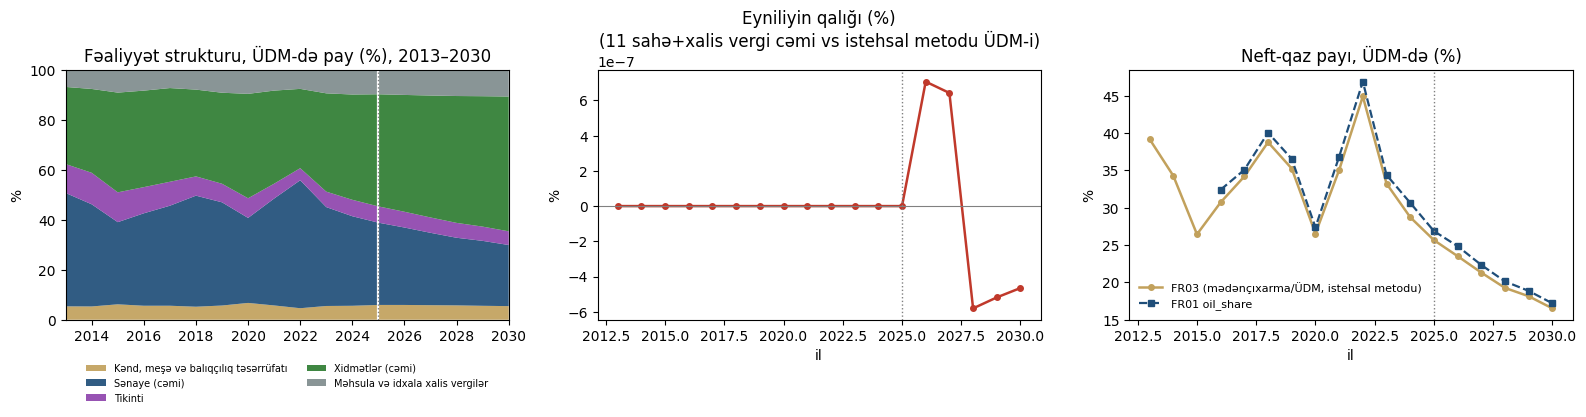

In [13]:
share5 = pd.DataFrame({BRANCH_NAME[k]: BR_LEVEL[k] for k in
                       ["agri", "industry", "constr", "services", "nettax"]})
share5_pct = share5.div(share5.sum(axis=1), axis=0) * 100

oil_share_br = (BR_LEVEL["industry_oil"] / GDP * 100)
oil_share_fr1 = from_fl("FR1", "oil_share").reindex(YEARS)

palette = ["#c2a15c", "#1f4e79", "#8e44ad", "#2e7d32", "#7f8c8d"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ax = axes[0]
ax.stackplot(share5_pct.index, [share5_pct[c].values for c in share5_pct.columns],
            labels=share5_pct.columns, colors=palette, alpha=0.92)
ax.axvline(LA, color="white", lw=1.6)
ax.axvline(LA, color="grey", ls=":", lw=1.0)
ax.set_title("Fəaliyyət strukturu, ÜDM-də pay (%), 2013–2030")
ax.set_ylabel("%"); ax.set_xlim(2013, 2030); ax.set_ylim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False, fontsize=7)

ax = axes[1]
ax.plot(gap_report.index, gap_report["gap_pct"].values, "-o", color="#c0392b", lw=1.8, ms=4)
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(LA, color="grey", ls=":", lw=1.0)
ax.set_title("Eyniliyin qalığı (%)\n(11 sahə+xalis vergi cəmi vs istehsal metodu ÜDM-i)")
ax.set_ylabel("%"); ax.set_xlabel("il")

ax = axes[2]
ax.plot(oil_share_br.index, oil_share_br.values, "-o", color="#c2a15c", lw=1.8, ms=4,
       label="FR03 (mədənçıxarma/ÜDM, istehsal metodu)")
ax.plot(oil_share_fr1.index, oil_share_fr1.values, "--s", color="#1f4e79", lw=1.6, ms=4,
       label="FR01 oil_share")
ax.axvline(LA, color="grey", ls=":", lw=1.0)
ax.set_title("Neft-qaz payı, ÜDM-də (%)")
ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR03_sahe_strukturu.png"), dpi=140, bbox_inches="tight")
plt.show()


## 9. Nəticələrin ixracı

In [14]:
ACT_ROOTS = ["agri", "industry", "industry_oil", "industry_nonoil", "constr", "services",
            "nettax", "total"]
ACT_NAME = dict(BRANCH_NAME); ACT_NAME["total"] = "ÜDM (5 budağın cəmi)"

fl_rows = []


def _add_level(root):
    nm = f"{ACT_NAME[root]} — əlavə dəyər (fəaliyyət strukturu)"
    s = BR_LEVEL[root]
    for y in YEARS:
        kind = "actual" if y <= LA else "forecast"
        fl_rows.append({"fr": "FR3", "series_code": f"va_act_{root}", "series_name_az": nm,
                        "unit": "mln AZN", "year": y, "kind": kind, "source": "ours",
                        "value": round(float(s.loc[y]), 3),
                        "lo80": None, "hi80": None, "lo50": None, "hi50": None})
    if root in BR_LEVEL_M:
        for y, v in BR_LEVEL_M[root].items():
            fl_rows.append({"fr": "FR3", "series_code": f"va_act_{root}", "series_name_az": nm,
                            "unit": "mln AZN", "year": int(y), "kind": "forecast",
                            "source": "template_sample", "value": round(float(v), 3),
                            "lo80": None, "hi80": None, "lo50": None, "hi50": None})


def _add_deflator(root):
    nm = f"{ACT_NAME[root]} — deflyator (həcm aqreqatının qalığı)"
    s = BR_DEFL[root]
    for y in YEARS:
        if y < 2014:
            continue          # deflyator indi QALIQDIR: t-1 olmadan tərifsizdir (artım kimi)
        kind = "actual" if y <= LA else "forecast"
        fl_rows.append({"fr": "FR3", "series_code": f"d_act_{root}", "series_name_az": nm,
                        "unit": "%", "year": y, "kind": kind, "source": "ours",
                        "value": round(float(s.loc[y]), 4),
                        "lo80": None, "hi80": None, "lo50": None, "hi50": None})


def _add_growth(root):
    nm = f"{ACT_NAME[root]} — real artım tempi (fəaliyyət strukturu)"
    s = BR_GROWTH[root]
    for y in YEARS:
        if y < 2014:
            continue                      # 2013 üçün böyümə tərifsizdir (t-1 yoxdur)
        kind = "actual" if y <= LA else "forecast"
        if kind == "forecast" and root in BANDS:
            b = BANDS[root].loc[y]
            fl_rows.append({"fr": "FR3", "series_code": f"g_act_{root}", "series_name_az": nm,
                            "unit": "%", "year": y, "kind": kind, "source": "ours",
                            "value": round(float(s.loc[y]), 4),
                            "lo80": round(float(b["lo80"]), 4), "hi80": round(float(b["hi80"]), 4),
                            "lo50": round(float(b["lo50"]), 4), "hi50": round(float(b["hi50"]), 4)})
        else:
            fl_rows.append({"fr": "FR3", "series_code": f"g_act_{root}", "series_name_az": nm,
                            "unit": "%", "year": y, "kind": kind, "source": "ours",
                            "value": round(float(s.loc[y]), 4),
                            "lo80": None, "hi80": None, "lo50": None, "hi50": None})


for root in ACT_ROOTS:
    _add_level(root)
    _add_deflator(root)
    _add_growth(root)

fl_df = pd.DataFrame(fl_rows)
outputs.write_forecast_long(fl_df)
print(f"forecast_long.csv-ə {len(fl_df)} sətir yazıldı (fr=FR3, {fl_df['series_code'].nunique()} seriya kodu)")


forecast_long.csv-ə 456 sətir yazıldı (fr=FR3, 24 seriya kodu)


In [15]:
dict_rows = []
for root in ACT_ROOTS:
    for prefix, suffix, unit in [("va", "əlavə dəyər", "mln AZN"), ("g", "real artım tempi", "%"),
                                 ("d", "deflyator", "%")]:
        dict_rows.append({"series_code": f"{prefix}_act_{root}",
                          "name_az": f"{ACT_NAME[root]} — {suffix}",
                          "name_en": f"{root} branch — {suffix}", "unit": unit, "fr": "FR3",
                          "statutory_sheet_ref": "8 vərəq, 2.4.1.3."})
dict_df = pd.DataFrame(dict_rows)
outputs.write_series_dictionary(dict_df)
print(f"series_dictionary.csv-ə {len(dict_df)} yeni kod əlavə edildi")

series_dictionary.csv-ə 24 yeni kod əlavə edildi


In [16]:
bt_rows = [BT[k].table for k in BRANCH_KEYS]
bt_all = pd.concat(bt_rows, ignore_index=True)
# bant ölçüləndirmə etalonu — model müqayisəsi deyil: bu sətirlər YALNIZ Bölmə 7.1-in yelpik
# zolağını ölçmək üçün aparılan RW sınağıdır (heç bir struktur tənlik qiymətləndirilmir, bax
# Bölmə 6). 'model'='RW' adı ilə yazılsaydı, sıra kodunu bir dashboard-un naiv oxunuşu RW-ni
# RW ilə müqayisə edib bacarığı avtomatik 0 %-ə endirərdi; ona görə etiket 'BANT_ETALONU'-dur.
bt_all["model"] = "BANT_ETALONU"
outputs.write_backtest(bt_all)
print(f"validation_backtest.csv-ə {len(bt_all)} sətir yazıldı (bant etalonu, {bt_all['series_code'].nunique()} seriya)")

validation_backtest.csv-ə 29 sətir yazıldı (bant etalonu, 7 seriya)


## 10. Məhdudiyyətlər

**Eynilik qüvvədədir.** Bölmə 3.1-də göstərildiyi kimi, istehsal metodunun balans eyniliyi
**ÜDM = Σ (11 sahənin əlavə dəyəri) + məhsula və idxala xalis vergilər** bu dəftərin oxuduğu bütün
2013–2030 illərində qapanır; qalıq fərq 0,005 mln AZN-i keçmir və yalnız `forecast_long.csv`
dəyərlərinin üç onluq işarə ilə yuvarlaqlaşdırılmasından gəlir. Bu dəftər heç bir düzəldici miqyaslama
aparmır — hər budağın səviyyəsi FR02-nin nəşr etdiyi rəqəmlərin birbaşa cəmidir. Uzlaşdırma hədəfinin
xalis vergilərdən təmizlənmiş səviyyə olması (FR02, Bölmə 7.4) məhz bu eyniliyin tələbidir: əks
halda vergilər ikiqat sayılardı.

**Aqreqasiya qaydası düzəldilib.** Əvvəlki buraxılışda deflyator ANKOR (komponent deflyatorlarının
CARİ il nominal payları ilə çəkili ortası), real artım isə QALIQ idi, və mətn bunu "iki mümkün
konvensiyadan biri" kimi təqdim edirdi. Bu, konvensiya seçimi deyil, **səhv idi**: cari il payları
qiymət sıçrayışı ilə birlikdə şişdiyi üçün qiymət dəyişməsi ikiqat sayılırdı və 2022-ci ildə ÜDM
üçün −3,5 % real artım verirdi (nəşr olunmuş dəyər +4,7 %). İndi həcm aqreqatı əvvəlki ilin
paylarıyla qurulur, deflyator qalıqdır (Bölmə 3.3) — bu, milli hesabların standart qaydası və
paketin FR01/FR02-də onsuz da işlətdiyi qaydadır. Sahə qiymət kanalı bundan **daha yaxşı** qorunur:
hər sahənin öz `d_i` yolu komponentin real artımını təyin etmək üçün olduğu kimi işlədilir.

**Xalis vergilərin həcm yolu artıq ölçüdür, proxy deyil.** Əvvəlki buraxılışda xalis vergilərin
"qiyməti" 11 sahənin VA-çəkili orta deflyatorundan uydurulur, real artım isə ondan qalıq kimi
çıxarılırdı — halbuki FR02 bu sıranın real artımını (`net_taxes_g`) ARTIQ nəşr edir. İndi həmin
nəşr olunan sıra birbaşa oxunur, deflyator isə qalıq kimi alınır.

**Sənaye-neft budağı (mədənçıxarma) FR01-in "neft-qaz sektoru" anlayışından geniş başa düşülür.**
Bu budaq bütöv mədənçıxarma sənayesidir (NACE təsnifatı), FR01-in neft-qaz bloku isə yalnız xam neft
və qaz hasilatının əlavə dəyəri üstəgəl həmin bloka aid xalis vergilərdir; qeyri-neft mədənçıxarma
(2025: 2 116,4 mln AZN) FR01-də qeyri-neft blokundadır. Bölmə 5 və Bölmə 8-də görünən fərq məhz bu
tərif fərqidir və o, **məcmu ÜDM-ə toxunmur** — yuxarıdakı eynilik hər il sıfır qalığı ilə qapanır.

**Xalis vergilərin öz "qiyməti" yoxdur.** VA-çəkili orta (11 sahənin deflyatoru üzərindən) proxy kimi
işlədilir — bu, FR02-nin YALNIZ proqnoz üfüqü üçün etdiyi seçimin bütün 2013–2030 dövrünə
genişləndirilməsidir; xalis vergilərin öz iqtisadi məzmunlu qiyməti olmadığından bu, sadələşdirmədir.

**Zolağın sadələşdirilməsi.** Struktur tənlik olmadığından (Bölmə 6), σ₁ YALNIZ RW-etalonun
nümunədən kənar RMSE-sidir. Bunu "alt sərhəd" adlandırmaq dəqiq deyil və əvvəlki mətn məhz belə
yazırdı: RW naiv etalondur və mərkəzi yolu daşıyan FR02 ansamblları onu üstələyir, ona görə σ₁
modelin öz xətasından BÖYÜKDÜR; digər tərəfdən o, tərif fərqini və aqreqasiya qeyri-müəyyənliyini
əhatə etmir. Yəni σ₁ nə alt, nə üst sərhəddir — **miqyas ölçüsüdür** və belə oxunmalıdır. Üstəlik
ortaq sınaq pəncərəsi cəmi dörd ildir (2022–2025), çünki budaq tarixçəsi 2014-dən başlayır və
`min_train = 8` tələb olunur; bu, xüsusilə tikinti və xalis vergilər budaqlarında (yüksək
dəyişkənlik) rəqəmi kövrək edir.

**Diversifikasiya barədə dürüst nəticə.** Rəqəmlərin özü göstərir ki, sənaye-neft budağının ÜDM-də payı
2013-cü ildəki ~39 %-dən 2025-ci ildə ~26 %-ə düşüb və bizim uzlaşdırılmış yolumuzda 2030-cu ilə qədər
~20 %-ə enməsi gözlənilir (şablon-nümunə ssenarisində bənzər istiqamətlə ~23 %); xidmətlər budağının
payı isə eyni dövrdə ən böyük budağa çevrilib. Bu, arzuolunan bir nərəziyyə deyil, uzlaşdırılmış
rəqəmlərin özünün göstərdiyi istiqamətdir.


## 11. Yoxlama

In [17]:
v = validate.Verifier("FR03 — Sahə strukturu")

# 1. Beş budağın cəmi istehsal metodu ÜDM-inə (FR02 `gdp_prod`) HƏR il üçün bərabərdir —
#    düzəldici miqyaslama OLMADAN; dözüm 0,1 mln AZN yalnız `forecast_long.csv`-in üç onluq
#    işarəli yuvarlaqlaşdırmasını əhatə edir
v.identity("5 budağın cəmi = ÜDM (istehsal metodu, 2013–2030, miqyaslama olmadan)",
          BR_LEVEL["total"], GDP, tol=0.1)

# 1b. İSTEHSAL METODUNA KEÇİD: FR01-in nəşr etdiyi ÜDM istehsal metodunun öz cəmi ilə HƏR il eynidir; deməli
#     fəaliyyət strukturunun cəmi də FR01-in ÜDM-inə bərabərdir. Dözüm 0,1 mln AZN — `forecast_long.csv`
#     üç onluq işarə ilə yazılır (BUILD_CONTEXT §6, 6-cı bənd).
v.identity("FR01-in ÜDM-i = istehsal metodu ilə ÜDM (istehsal metoduna keçid, hər il)", GDP_FR1, GDP, tol=0.1)
v.identity("5 budağın cəmi = FR01-in ÜDM-i (hər il)", BR_LEVEL["total"], GDP_FR1, tol=0.1)

# 2. Sənaye = neft + qeyri-neft (müstəqil yenidən yığım)
v.identity("sənaye = sənaye-neft + sənaye-qeyri-neft", BR_LEVEL["industry"],
          BR_LEVEL["industry_oil"] + BR_LEVEL["industry_nonoil"], tol=1e-6)

# 3. Xidmətlər = 5 alt-sahənin cəmi — TAMAMILƏ MÜSTƏQİL kod yolu ilə yenidən hesablanır
v.identity("xidmətlər = 5 alt-sahənin cəmi (müstəqil yenidən yığım)", BR_LEVEL["services"],
          sum(VA_R[c] for c in SERVICE_SECTORS), tol=1e-6)

# 4. müstəqil yenidən hesablama: 2030-cu il ÜDM-i 12 komponentin BİRBAŞA cəmindən (budaq iyerarxiyası
#    olmadan) törədilir və BR_LEVEL["total"]-la tutuşdurulur
def _yeniden_hesabla_total_2030():
    return float(sum(parts_bal[c].loc[2030] for c in SECTOR_ROOTS) + parts_bal["net_taxes"].loc[2030])

v.recompute("ÜDM 2030 (12 komponentin birbaşa cəmindən yenidən hesablanır)",
           shipped=float(BR_LEVEL["total"].loc[2030]), fn=_yeniden_hesabla_total_2030, tol=1e-6)

# 5. səviyyə-artım-deflyator eyniliyinin öz-özünə uyğunluğu (2026, iki budaq üçün nöqtə yoxlaması)
for k in ["industry_oil", "services"]:
    def _chain_check(k=k):
        return float(BR_LEVEL[k].loc[2025] * (1 + BR_GROWTH[k].loc[2026] / 100) * (1 + BR_DEFL[k].loc[2026] / 100))
    v.recompute(f"səviyyə=əvvəlki×(1+g)×(1+d) eyniliyi, {BRANCH_NAME[k]} 2026",
               shipped=float(BR_LEVEL[k].loc[2026]), fn=_chain_check, tol=1e-6)

# 6. Nazirliyin öz 8-vərəq cəmi öz ÜDM bazası ilə üst-üstə düşür (müstəqil müşahidə, yoxlama deyil, amma
#    təsdiq üçün eyni Verifier alətindən istifadə edilir)
v.identity("Nazirliyin öz cəmi = Nazirliyin öz ÜDM bazası (2026-2030)", BR_LEVEL_M["total"], GDP_M,
          tol=1e-3)

# 7. gələcəyə baxış yoxdur: ADF/backtest üçün istifadə olunan tarixi hissə heç vaxt 2025-i keçmir
for k in BRANCH_KEYS:
    hist = BR_GROWTH[k].loc[:LA].dropna()
    v.no_lookahead(f"budaq real artım tarixçəsi ({BRANCH_NAME[k]})", hist.index)

# 8. ansambl/zolaq — RW RMSE-nin özü mənfi olmamalıdır (sağlamlıq)
for k in BRANCH_KEYS:
    if BT[k].rw_rmse is not None:
        v.ok(f"RW RMSE mənfi deyil ({BRANCH_NAME[k]})", BT[k].rw_rmse >= 0)

v.assert_all()


  YOXLAMA: FR03 — Sahə strukturu
  [PASS] eynilik: 5 budağın cəmi = ÜDM (istehsal metodu, 2013–2030, miqyaslama olmadan)
         18 il, maksimal fərq 1.000e-03
  [PASS] eynilik: FR01-in ÜDM-i = istehsal metodu ilə ÜDM (istehsal metoduna keçid, hər il)
         18 il, maksimal fərq 1.000e-03
  [PASS] eynilik: 5 budağın cəmi = FR01-in ÜDM-i (hər il)
         18 il, maksimal fərq 2.000e-03
  [PASS] eynilik: sənaye = sənaye-neft + sənaye-qeyri-neft
         18 il, maksimal fərq 0.000e+00
  [PASS] eynilik: xidmətlər = 5 alt-sahənin cəmi (müstəqil yenidən yığım)
         18 il, maksimal fərq 0.000e+00
  [PASS] yenidən hesablama: ÜDM 2030 (12 komponentin birbaşa cəmindən yenidən hesablanır)
         maksimal fərq 0.000e+00 ≤ 1.0e-06
  [PASS] yenidən hesablama: səviyyə=əvvəlki×(1+g)×(1+d) eyniliyi, Sənaye — neft-qaz (mədənçıxarma) 2026
         maksimal fərq 0.000e+00 ≤ 1.0e-06
  [PASS] yenidən hesablama: səviyyə=əvvəlki×(1+g)×(1+d) eyniliyi, Xidmətlər (cəmi) 2026
         maksimal fərq 0.000

In [18]:
fl_disk = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
dict_disk = pd.read_csv(os.path.join(config.OUT, "series_dictionary.csv"))
bt_disk2 = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"))

print("forecast_long.csv, FR3 sətirləri     :", int((fl_disk["fr"] == "FR3").sum()))
print("  o cümlədən şablon overlay-i        :",
      int(((fl_disk["fr"] == "FR3") & (fl_disk["source"] == "template_sample")).sum()))
print("series_dictionary.csv, act_ kodları  :",
      int(dict_disk["series_code"].str.contains("_act_").sum()))
print("validation_backtest.csv, g_act_ sıraları:",
      int(bt_disk2["series_code"].str.match(r"^g_act_").sum()))

# müstəqil, DİSKDƏN oxunan son yoxlama: FR3-ün va_act_ kökləri istehsal metodu ÜDM-inə
# (FR02 `gdp_prod`, 5 əsas budaq üzrə) bərabərdir
chk = fl_disk[(fl_disk["fr"] == "FR3") & (fl_disk["source"] == "ours") &
             (fl_disk["series_code"].isin([f"va_act_{k}" for k in
                                           ["agri", "industry", "constr", "services", "nettax"]]))]
piv = chk.pivot_table(index="year", columns="series_code", values="value", aggfunc="first")
disk_total = piv.sum(axis=1)
gdp_disk = fl_disk[(fl_disk["fr"] == "FR2") & (fl_disk["series_code"] == "gdp_prod") &
                   (fl_disk["source"] == "ours")].set_index("year")["value"]
diff_disk = (disk_total - gdp_disk.reindex(disk_total.index)).abs()
print(f"\nDiskdən oxunan son yoxlama — maksimal mütləq fərq: {float(diff_disk.max()):.2e} mln AZN "
      f"({len(disk_total)} il)")
# dözüm 0,1 mln AZN: qalıq yalnız `forecast_long.csv`-in üç onluq işarəli yuvarlaqlaşdırmasından
# yığılır (11 sahə + xalis vergi + budaq səviyyələri). Düzəldici miqyaslama tətbiq edilmədiyi üçün
# (Bölmə 3.2) bu qalıq gizlədilmir, ölçülür.
assert float(diff_disk.max()) < 0.1, "diskdəki FR3 sətirləri istehsal metodu ÜDM-inə uyğun gəlmir"
print("bütün gözlənilən seriyalar forecast_long.csv-də mövcuddur və eynilik diskdən təsdiqlənir.")

forecast_long.csv, FR3 sətirləri     : 456
  o cümlədən şablon overlay-i        : 40
series_dictionary.csv, act_ kodları  : 24
validation_backtest.csv, g_act_ sıraları: 29

Diskdən oxunan son yoxlama — maksimal mütləq fərq: 1.00e-03 mln AZN (18 il)
bütün gözlənilən seriyalar forecast_long.csv-də mövcuddur və eynilik diskdən təsdiqlənir.
